# NetworkX: Network Properties & Centrality Analysis
*A comprehensive guide to quantifying graph topology, node importance, and network flow.*

---

Welcome to **Notebook 2** of our NetworkX series! 

In Notebook 1, you mastered the foundational mechanics of graph construction: adding nodes and edges, working with edge attributes, selecting graph varieties (`Graph`, `DiGraph`, `MultiDiGraph`), and rendering visual layouts.

Now, we shift from **graph creation** to **graph analysis**:
1. **Global Network Metrics:** Quantifying density, connectivity, diameter, and path distances.
2. **Centrality Measures:** Identifying critical entities through Degree, Closeness, and Betweenness centrality.
3. **Directed Influence & Authority:** Applying the PageRank algorithm.
4. **Visualizing Importance:** Mapping quantitative metrics dynamically to node sizes and colormaps.
5. **Hands-On Exercises:** Consolidating your understanding through targeted challenges.


### 1. Setup & Environment
Let's import `networkx`, `matplotlib.pyplot`, and `numpy`. We'll also configure Matplotlib defaults to ensure crisp, readable visualizations.


In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

# Configure visual styling
plt.rcParams["figure.dpi"] = 100
plt.rcParams["font.sans-serif"] = "DejaVu Sans"

print(f"NetworkX Version: {nx.__version__}")


NetworkX Version: 3.4.2


### 2. Macroscopic (Global) Network Properties
Global properties summarize the overall structure, density, and communication efficiency of an entire network.

Let's generate a benchmark social collaboration network (Krackhardt Kite Graph or a synthetic social network) to observe these properties in action:
*   **Density:** The ratio of actual edges to possible edges. In an undirected graph with $n$ nodes, maximum edges are $\frac{n(n-1)}{2}$.
*   **Connected Components:** Isolated or reachable subgraphs. A path must exist between all node pairs for a graph to be fully connected.
*   **Diameter:** The longest shortest path (geodesic distance) between any pair of reachable nodes.
*   **Average Shortest Path Length:** The characteristic communication distance across the network.


In [2]:
# Create a sample collaboration network
G = nx.Graph()

# Add relationships with weights representing collaborative interactions
edges = [
    ("Alice", "Bob", 4),
    ("Alice", "Charlie", 2),
    ("Bob", "Charlie", 1),
    ("Bob", "Diana", 5),
    ("Charlie", "Diana", 2),
    ("Charlie", "Eve", 3),
    ("Diana", "Eve", 2),
    ("Diana", "Frank", 6),
    ("Eve", "Frank", 3),
    ("Frank", "Gita", 4),
    ("Gita", "Hank", 2)
]

for u, v, w in edges:
    G.add_edge(u, v, weight=w)

# 1. Network Density
density = nx.density(G)

# 2. Connectivity & Components
is_connected = nx.is_connected(G)
num_components = nx.number_connected_components(G)

# 3. Path Metrics (Valid only for connected graphs)
if is_connected:
    diameter = nx.diameter(G)
    avg_path_length = nx.average_shortest_path_length(G)
else:
    diameter = float("inf")
    avg_path_length = float("inf")

print(f"Total Nodes: {G.number_of_nodes()}")
print(f"Total Edges: {G.number_of_edges()}")
print(f"Network Density: {density:.4f}")
print(f"Is Fully Connected?: {is_connected} ({num_components} component)")
print(f"Network Diameter: {diameter}")
print(f"Average Shortest Path Length: {avg_path_length:.4f}")


Total Nodes: 8
Total Edges: 11
Network Density: 0.3929
Is Fully Connected?: True (1 component)
Network Diameter: 5
Average Shortest Path Length: 2.1071


#### Handling Disconnected Graphs
If a network contains isolated nodes or disconnected clusters, calculating `nx.diameter(G)` will raise a `NetworkXError`. In production pipelines, always inspect connected components first or evaluate metrics on the **largest connected component (LCC)**.


In [3]:
# Demonstrate component extraction on a graph with an isolated cluster
G_disconnected = G.copy()
G_disconnected.add_edge("Isolate_1", "Isolate_2", weight=1)

# Extract connected components sorted by size
components = list(nx.connected_components(G_disconnected))
print(f"Total separate subgraphs: {len(components)}")

# Get the Largest Connected Component (LCC) subgraph
lcc_nodes = max(nx.connected_components(G_disconnected), key=len)
LCC = G_disconnected.subgraph(lcc_nodes).copy()

print(f"Nodes in LCC: {list(LCC.nodes())}")
print(f"Diameter of LCC: {nx.diameter(LCC)}")


Total separate subgraphs: 2
Nodes in LCC: ['Alice', 'Bob', 'Charlie', 'Diana', 'Eve', 'Frank', 'Gita', 'Hank']
Diameter of LCC: 5


### 3. Node-Level Importance: Centrality Measures
Centrality answers the foundational question: **"Which node is the most critical to this network?"**

Depending on how you define "critical", NetworkX provides multiple standard mathematical algorithms:

| Metric | Intuition | Formula Context | NetworkX API |
| :--- | :--- | :--- | :--- |
| **Degree Centrality** | **Popularity:** Who has the most direct connections? | Fraction of nodes connected to $u$: $\frac{deg(u)}{N-1}$ | `nx.degree_centrality(G)` |
| **Closeness Centrality** | **Reachability:** Who can spread information fastest? | Reciprocal of the sum of shortest path distances to all other nodes. | `nx.closeness_centrality(G)` |
| **Betweenness Centrality** | **Gatekeeping:** Who controls or bottlenecks information flows? | Proportion of all pairwise shortest paths that traverse node $u$. | `nx.betweenness_centrality(G)` |
| **Eigenvector Centrality** | **Prestige:** Who is connected to other highly influential nodes? | Proportional to the sum of centralities of its neighbors. | `nx.eigenvector_centrality(G)` |


In [4]:
# Compute standard centrality metrics on our collaboration graph G
deg_centrality = nx.degree_centrality(G)
closeness_centrality = nx.closeness_centrality(G)
betweenness_centrality = nx.betweenness_centrality(G)
eigen_centrality = nx.eigenvector_centrality(G, max_iter=500)

# Aggregate into a formatted comparison table
import pandas as pd

centrality_df = pd.DataFrame({
    "Degree": deg_centrality,
    "Closeness": closeness_centrality,
    "Betweenness": betweenness_centrality,
    "Eigenvector": eigen_centrality
}).round(4)

centrality_df.sort_values(by="Betweenness", ascending=False)


,Degree,Closeness,Betweenness,Eigenvector
Frank,0.4286,0.5833,0.4762,0.3161
Diana,0.5714,0.6364,0.3333,0.5002
Gita,0.2857,0.4375,0.2857,0.1089
Charlie,0.5714,0.5385,0.1905,0.4905
Eve,0.4286,0.5833,0.1190,0.4067
Bob,0.4286,0.5000,0.0714,0.3939
Alice,0.2857,0.3889,0.0000,0.2752
Hank,0.1429,0.3182,0.0000,0.0339


Notice the structural contrast between **Charlie / Diana** and **Frank**:
*   **Diana** and **Charlie** have high **Degree** (many local friends).
*   **Frank**, however, acts as the indispensable **bridge** connecting the tight core ("Alice", "Bob", "Charlie", "Diana", "Eve") to the peripheral nodes ("Gita" and "Hank"). Hence, **Frank dominates Betweenness Centrality**!


### 4. Directed Influence: In-Degree, Out-Degree, and PageRank
In a directed graph (`nx.DiGraph`), connections are asymmetric. Node importance splits into:
*   **Out-Degree Centrality:** Propensity to broadcast or trigger flows.
*   **In-Degree Centrality:** Popularity or endorsement by other nodes.
*   **PageRank:** A random-walk algorithm that measures node authority based on the quantity and quality of incoming links.


In [7]:
# Build an applied Directed Knowledge / Dependency Network
dependency_graph = nx.DiGraph()

edges_dir = [
    ("Neural Network", "Deep Learning"),
    ("Gradient Descent", "Deep Learning"),
    ("Backpropagation", "Gradient Descent"),
    ("Deep Learning", "Transformer"),
    ("Attention Mechanism", "Transformer"),
    ("Transformer", "Large Language Model"),
    ("Large Language Model", "GraphRAG"),
    ("Knowledge Graph", "GraphRAG"),
    ("Vector DB", "GraphRAG")
]

dependency_graph.add_edges_from(edges_dir)

# 1. In-Degree Centrality vs Out-Degree Centrality
in_deg = nx.in_degree_centrality(dependency_graph)
out_deg = nx.out_degree_centrality(dependency_graph)

# 2. PageRank (damping factor alpha=0.85)
pagerank_scores = nx.pagerank(dependency_graph, alpha=0.85)

dir_df = pd.DataFrame({
    "In-Degree (Popularity)": in_deg,
    "Out-Degree (Broadcast)": out_deg,
    "PageRank (Authority)": pagerank_scores
}).round(4)

dir_df.sort_values(by="PageRank (Authority)", ascending=False)


,In-Degree (Popularity),Out-Degree (Broadcast),PageRank (Authority)
GraphRAG,0.3333,0.0000,0.2582
Large Language Model,0.1111,0.1111,0.1864
Transformer,0.2222,0.1111,0.1758
Deep Learning,0.2222,0.1111,0.1265
Gradient Descent,0.1111,0.1111,0.0684
Neural Network,0.0000,0.1111,0.0369
Attention Mechanism,0.0000,0.1111,0.0369
Backpropagation,0.0000,0.1111,0.0369
Knowledge Graph,0.0000,0.1111,0.0369
Vector DB,0.0000,0.1111,0.0369


### 5. Advanced Visualizations: Mapping Centrality to Node Geometry
A key best practice in network visualization is **encoding analytical data directly into graphical channels**:
*   **Node Size:** Proportional to Betweenness or Degree Centrality.
*   **Node Color:** Continuous colormap representing Closeness Centrality or PageRank.
*   **Colorbars:** Providing clear numeric references for readers.


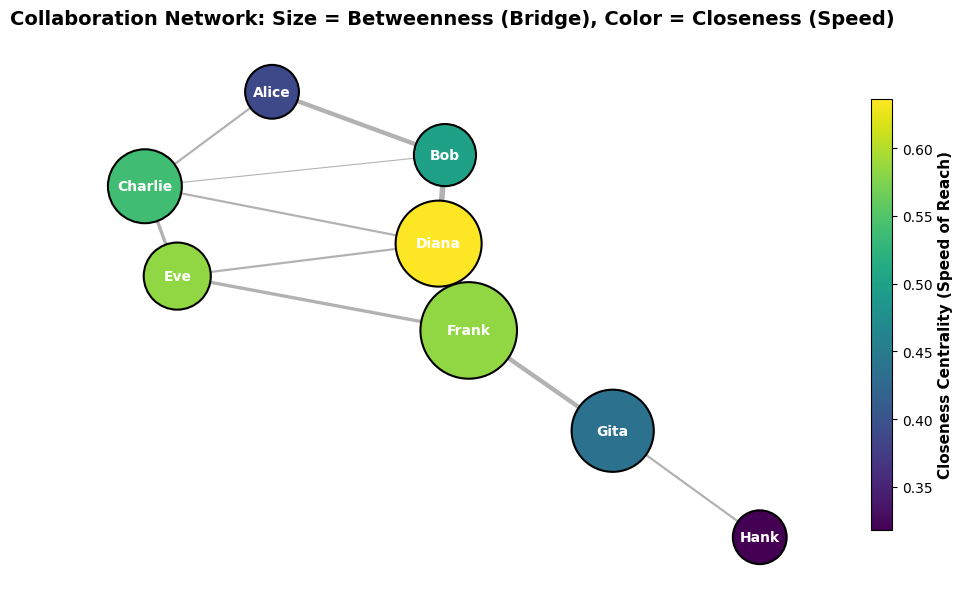

In [8]:
# Visualization: Collaboration Network with Dual Centrality Encoding
plt.figure(figsize=(12, 7))

pos = nx.spring_layout(G, seed=42, k=0.8)

# Calculate sizing from Betweenness Centrality (scale up for visual impact)
node_sizes = [1500 + 7000 * betweenness_centrality[node] for node in G.nodes()]

# Calculate colors from Closeness Centrality
closeness_values = [closeness_centrality[node] for node in G.nodes()]

# 1. Draw Edges with thickness mapped to relationship weight
edge_weights = [G[u][v]['weight'] for u, v in G.edges()]
nx.draw_networkx_edges(G, pos, width=[0.8 * w for w in edge_weights], alpha=0.6, edge_color="gray")

# 2. Draw Nodes with scalar colormap
nodes_scatter = nx.draw_networkx_nodes(
    G, pos, 
    node_size=node_sizes, 
    node_color=closeness_values, 
    cmap=plt.cm.viridis, 
    edgecolors="black", 
    linewidths=1.5
)

# 3. Draw Labels
nx.draw_networkx_labels(G, pos, font_size=10, font_weight="bold", font_color="white")

# 4. Add Colorbar referencing Closeness Centrality
sm = plt.cm.ScalarMappable(cmap=plt.cm.viridis, norm=plt.Normalize(vmin=min(closeness_values), vmax=max(closeness_values)))
sm.set_array([])
cbar = plt.colorbar(sm, ax=plt.gca(), orientation="vertical", shrink=0.8)
cbar.set_label("Closeness Centrality (Speed of Reach)", fontsize=11, fontweight="bold")

plt.title("Collaboration Network: Size = Betweenness (Bridge), Color = Closeness (Speed)", fontsize=14, fontweight="bold", pad=15)
plt.axis("off")
plt.show()


---
### 6. Exercises
Test your understanding of macroscopic network metrics, centrality computation, and visual encoding with the following three hands-on challenges.


#### Exercise 1: Finding Network Bottlenecks
1. Load or generate a Barabási-Albert preferential attachment graph: `G_ba = nx.barabasi_albert_graph(n=30, m=2, seed=42)`.
2. Compute the **Diameter** and **Average Shortest Path Length** of `G_ba`.
3. Identify the node with the highest **Betweenness Centrality** and print its ID along with its top 3 neighboring connections.


In [ ]:
# Write your Exercise 1 code here:


#### Exercise 2: Directed Citation Authority
1. Construct a small directed citation network of 6 academic papers (e.g., "Paper_1" through "Paper_6").
2. Add directed edges representing paper citations (e.g., `("Paper_6", "Paper_1")` indicates Paper 6 cites Paper 1).
3. Compute `nx.pagerank()`. Which paper emerges as the seminal foundational reference, and why?


In [ ]:
# Write your Exercise 2 code here:


#### Exercise 3: Visualizing Critical Gatekeepers
1. Using the undirected collaboration graph `G` from Section 2, compute `nx.degree_centrality(G)`.
2. Produce a visualization where:
   * **Node size** is scaled by **Degree Centrality**.
   * **Node color** is mapped to **Betweenness Centrality** using the `plasma` colormap.
   * Add a corresponding colorbar titled **"Betweenness Centrality"**.
3. Display the resulting figure with a descriptive title.


In [ ]:
# Write your Exercise 3 code here:
